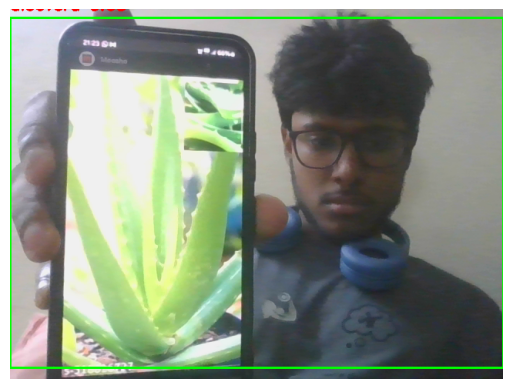


0: 256x320 1 aloevera, 70.6ms
Speed: 2.5ms preprocess, 70.6ms inference, 0.9ms postprocess per image at shape (1, 3, 256, 320)
Detected: aloevera at (0,11) to (640,465) | Confidence: 0.68


In [ ]:
import cv2
from ultralytics import YOLO
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# Load the YOLO model
model = YOLO(r"C:\Users\91939\OneDrive\Desktop\python\data\runs\detect\retry_aloevera_banana\weights\best.pt")

# Class names
class_names = ['aloevera', 'banana']

# Start video capture
cap = cv2.VideoCapture(0)

conf_threshold = 0.25

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame.")
            break

        results = model(frame)

        for r in results:
            for box in r.boxes:
                conf = float(box.conf[0])
                if conf > conf_threshold:
                    cls_id = int(box.cls[0])
                    name = class_names[cls_id] if cls_id < len(class_names) else f"Class {cls_id}"
                    x1, y1, x2, y2 = map(int, box.xyxy[0])

                    color = (0, 165, 255) if name == "banana" else (0, 255, 0)

                    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                    cv2.putText(frame, f"{name} {conf:.2f}", (x1, y1 - 10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
                    print(f"Detected: {name} at ({x1},{y1}) to ({x2},{y2}) | Confidence: {conf:.2f}")

        # Convert BGR to RGB for display in notebook
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Display the frame in the notebook
        clear_output(wait=True)
        plt.imshow(rgb_frame)
        plt.axis('off')
        display(plt.gcf())

except KeyboardInterrupt:
    print("Stopped.")

cap.release()
